## Diabetes Prediction

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
diabetes_df = pd.read_csv('../data/diabetes.csv')

In [3]:
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
diabetes_df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [5]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
rows = diabetes_df.shape[0]
columns = diabetes_df.shape[1]

print(f'Rows - {rows}\nColumns - {columns}')

Rows - 768
Columns - 9


In [10]:
diabetes_df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

## Data cleaning

In [11]:
#Checking for nulls

diabetes_df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [12]:
#Checking for nulls

diabetes_df.isnull().sum().sum()

np.int64(0)

In [13]:
#Check for duplicates

print(diabetes_df.duplicated().sum())

0


In [14]:
diabetes_df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Exploratory Data Analysis

In [21]:
corr_matrix = diabetes_df.corr()['Outcome']

In [22]:
corr_matrix

Pregnancies                 0.221898
Glucose                     0.466581
BloodPressure               0.065068
SkinThickness               0.074752
Insulin                     0.130548
BMI                         0.292695
DiabetesPedigreeFunction    0.173844
Age                         0.238356
Outcome                     1.000000
Name: Outcome, dtype: float64

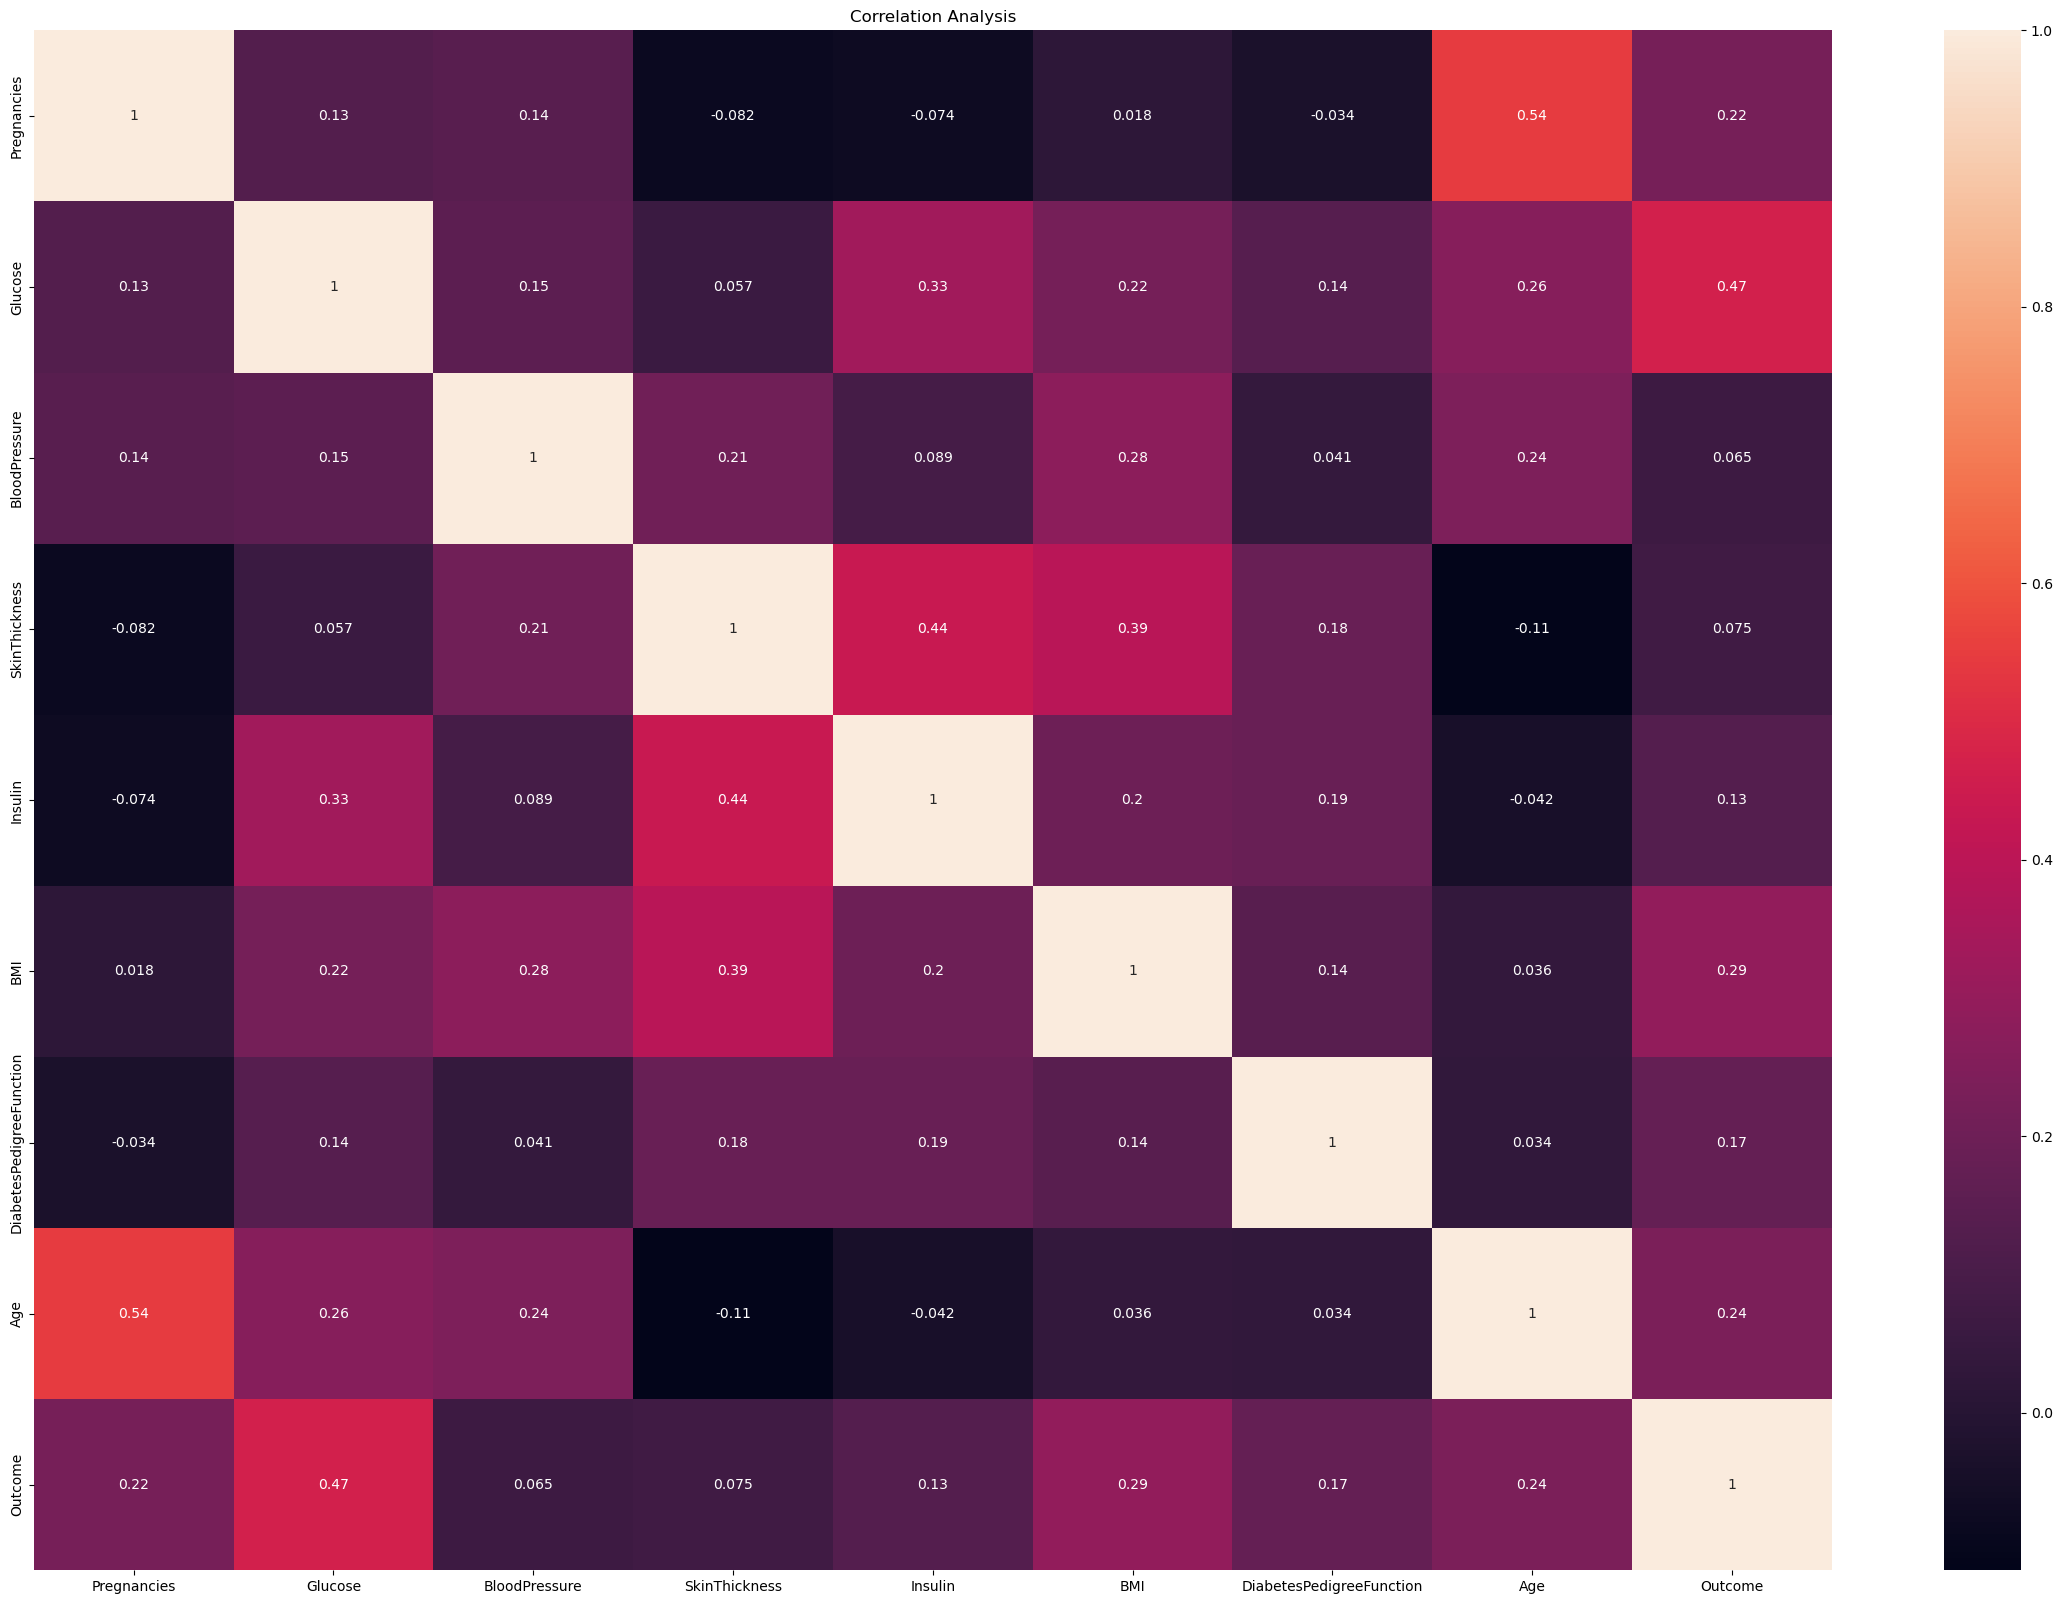

In [23]:
plt.figure(figsize = (29, 20))
sns.heatmap(data = diabetes_df.corr(), annot = True)
plt.title('Correlation Analysis')
plt.show()

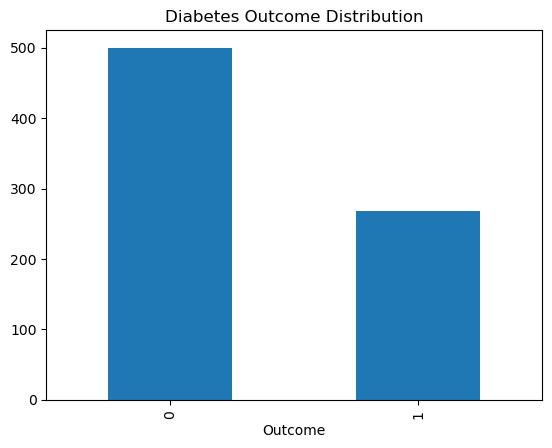

In [24]:
diabetes_df["Outcome"].value_counts().plot(kind="bar")
plt.title("Diabetes Outcome Distribution")
plt.show()

## Modeling

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

In [26]:
x = diabetes_df.drop('Outcome',axis=1)
y = diabetes_df['Outcome']

In [27]:
numeric_cols = x.select_dtypes(include = ['number']).columns.tolist()
categorical_cols = x.select_dtypes(include = ['object']).columns.tolist()


In [28]:
numeric_cols

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

In [32]:
categorical_cols

[]

## Pipeline

In [33]:
numeric_pipeline = Pipeline(steps=[('numericPipeline', StandardScaler())])
categorical_pipeline = Pipeline(steps = [('categoricalPipeline', OneHotEncoder(handle_unknown = 'ignore'))])

In [34]:
from sklearn.compose import ColumnTransformer

In [35]:
# Preprocessing Pipeline
ml_preprocess = ColumnTransformer(

    transformers = [

        ('TransformNumeric', numeric_pipeline, numeric_cols),
        ('TransformCategory', categorical_pipeline, categorical_cols), 
    ]
    
)

In [36]:
from sklearn.model_selection import train_test_split

In [40]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.2)

In [41]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import(
accuracy_score,
precision_score,
recall_score,
f1_score,
confusion_matrix,
ConfusionMatrixDisplay,
classification_report
)

In [42]:
lr_model = Pipeline(steps=[
    ('preprocess', ml_preprocess),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [43]:
dt_model = Pipeline(steps=[
    ('preprocess', ml_preprocess),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

In [44]:
rf_model = Pipeline(steps=[
    ('preprocess', ml_preprocess),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [56]:
nb_model = Pipeline(steps=[
    ('preprocess', ml_preprocess),
    ('classifier', GaussianNB())
])

In [57]:
knn_model = Pipeline(steps=[
    ('preprocess', ml_preprocess),
    ('classifier', KNeighborsClassifier())
])

In [58]:
svm_model = Pipeline(steps=[
    ('preprocess', ml_preprocess),
    ('classifier', SVC(probability=True, random_state=42))
])

In [59]:
models = {
    'Logistic Regression': lr_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'Naive Bayes': nb_model,
    'KNN': knn_model, 
    'SVM': svm_model
}

## Training the models

In [60]:
for name, model in models.items():
    model.fit(x_train, y_train)
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
Naive Bayes trained successfully.
KNN trained successfully.
SVM trained successfully.


In [61]:
lr_model.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('TransformNumeric', ...), ('TransformCategory', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [62]:
dt_model.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('TransformNumeric', ...), ('TransformCategory', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [63]:
rf_model.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('TransformNumeric', ...), ('TransformCategory', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [64]:
nb_model.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('TransformNumeric', ...), ('TransformCategory', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [65]:
knn_model.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('TransformNumeric', ...), ('TransformCategory', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [66]:
svm_model.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('TransformNumeric', ...), ('TransformCategory', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Testing the models

In [67]:
lr_y = lr_model.predict(x_test)
dt_y = dt_model.predict(x_test)
rf_y = rf_model.predict(x_test)
nb_y = nb_model.predict(x_test)
knn_y = knn_model.predict(x_test)
svm_y = svm_model.predict(x_test)

## Performance Evaluation

In [68]:
y_test.value_counts()

Outcome
0    99
1    55
Name: count, dtype: int64

In [101]:
results = []

for name, model in models.items():

    y_pred = model.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 score': f1
    })

    print('=' * 60)
    print(name)
    print('=' * 60)
    print(classification_report(y_test, y_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.79      0.78      0.78        99
           1       0.61      0.62      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154

Decision Tree
              precision    recall  f1-score   support

           0       0.83      0.76      0.79        99
           1       0.62      0.73      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154

Random Forest
              precision    recall  f1-score   support

           0       0.79      0.78      0.78        99
           1       0.61      0.62      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72   

In [102]:
results_df = pd.DataFrame(results)

results_df.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy,Precision,Recall,F1 score
3,Naive Bayes,0.766234,0.661017,0.709091,0.684211
1,Decision Tree,0.746753,0.625000,0.727273,0.672269
5,SVM,0.733766,0.645833,0.563636,0.601942
0,Logistic Regression,0.720779,0.607143,0.618182,0.612613
2,Random Forest,0.720779,0.607143,0.618182,0.612613
4,KNN,0.694805,0.583333,0.509091,0.543689


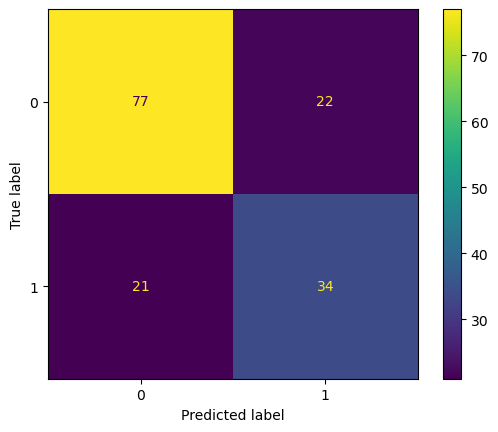

In [103]:
ConfusionMatrixDisplay.from_predictions(y_test, lr_y)
plt.show()

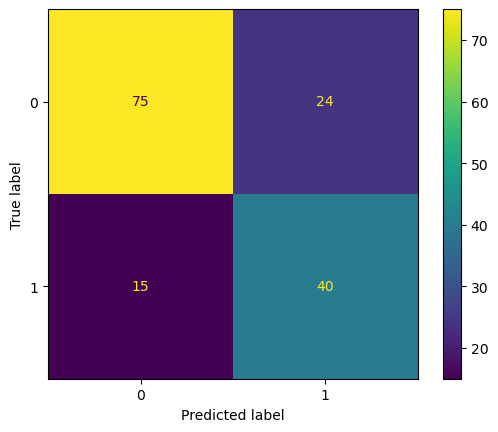

In [104]:
ConfusionMatrixDisplay.from_predictions(y_test, dt_y)
plt.show()

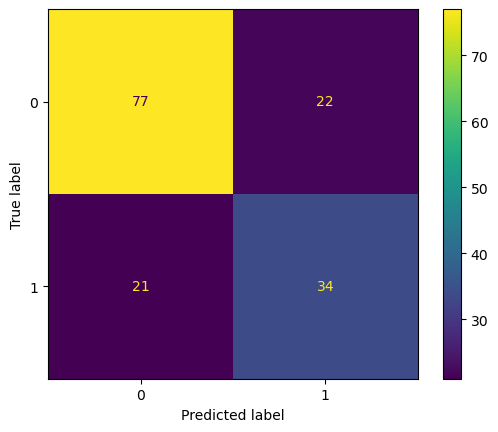

In [105]:
ConfusionMatrixDisplay.from_predictions(y_test, rf_y)
plt.show()

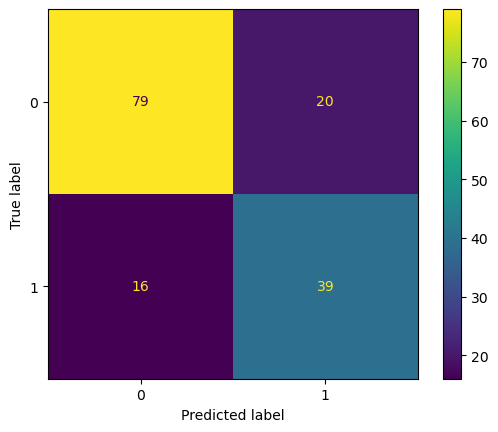

In [106]:
ConfusionMatrixDisplay.from_predictions(y_test, nb_y)
plt.show()

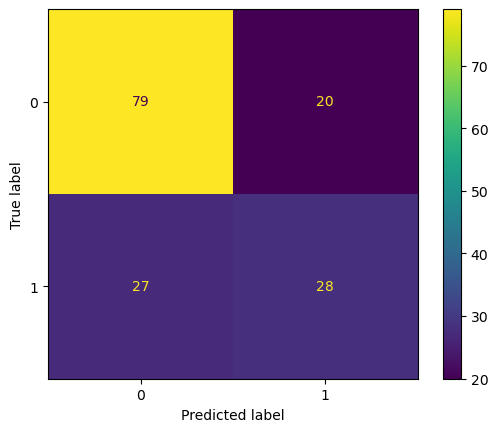

In [107]:
ConfusionMatrixDisplay.from_predictions(y_test, knn_y)
plt.show()

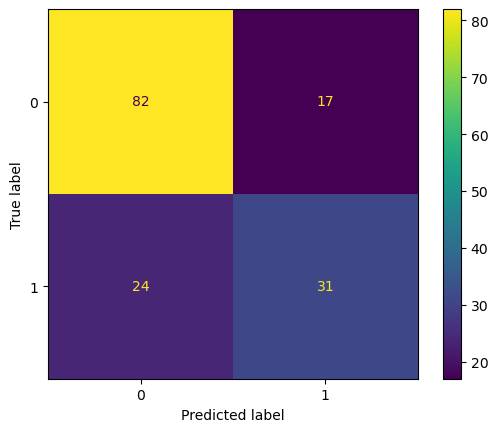

In [108]:
ConfusionMatrixDisplay.from_predictions(y_test, svm_y)
plt.show()

In [110]:
best_model = results_df.sort_values(
    by='Accuracy',
    ascending=False
).iloc[0]

print(best_model)

Model        Naive Bayes
Accuracy        0.766234
Precision       0.661017
Recall          0.709091
F1 score        0.684211
Name: 3, dtype: object


In [111]:
import joblib

joblib.dump(nb_model, '../Model/loan_approval_pipeline.pkl')

['../Model/loan_approval_pipeline.pkl']

In [112]:
pipeline = joblib.load('../Model/loan_approval_pipeline.pkl')